# Agenda

1. Dates and times
2. Plotting


# Dates and times

When we talk about "time" in human language, we're really describing (at least) two different things. In a computer, these have typically been divided into two types of data structures:

- `datetime` or `timestamp` -- this is a unique moment in time, identified uniquely by its year, month, day, hour, minute, second, etc. Different systems will use different granularities.
- `timedelta` or `interval` -- this is a stretch of time between datetime values. It has a length (measured in years, months, days, etc), but it doesn't have a fixed starting time or ending time.

You could say: This class starts at a particular `datetime`. It lasts for a `timedelta`. 

In Python and in Pandas, both of these data structures are used to keep track of time. You can, in your data frame, have a column with a dtype of `datetime` or of `timedelta`. 

You can even do date arithmetic:

- `datetime` - `datetime` = `timedelta`
- `datetime` + `timedelta` = `datetime`

For example: I have someone's day of birth. I know how long they lived. I can use this date artithmetic to calculate when they died.

In Pandas, we can specify that a column is a `datetime`. However, when we read a file in, even if it contains what look like datetime values, Pandas won't use them as datetimes. We need to give it a bit a reminder, or a push, to see that and use the appropriate dtype.

This is changing - we've used NumPy as the back end for storage. Little by little, PyArrow is replacing NumPy in Pandas. Its loading system for CSV files does try to identify dates and times, and does try to make them into the dtypes for those columns.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('taxi.csv')

In [3]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2015-06-02 11:19:29,2015-06-02 11:47:52,1,1.63,-73.954430,40.764141,1,N,-73.974754,40.754093,2,17.0,0.0,0.5,0.00,0.0,0.3,17.80
1,2,2015-06-02 11:19:30,2015-06-02 11:27:56,1,0.46,-73.971443,40.758942,1,N,-73.978539,40.761909,1,6.5,0.0,0.5,1.00,0.0,0.3,8.30
2,2,2015-06-02 11:19:31,2015-06-02 11:30:30,1,0.87,-73.978111,40.738434,1,N,-73.990273,40.745438,1,8.0,0.0,0.5,2.20,0.0,0.3,11.00
3,2,2015-06-02 11:19:31,2015-06-02 11:39:02,1,2.13,-73.945892,40.773529,1,N,-73.971527,40.760330,1,13.5,0.0,0.5,2.86,0.0,0.3,17.16
4,1,2015-06-02 11:19:32,2015-06-02 11:32:49,1,1.40,-73.979088,40.776772,1,N,-73.982162,40.758999,2,9.5,0.0,0.5,0.00,0.0,0.3,10.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,1,2015-06-01 00:12:59,2015-06-01 00:24:18,1,2.70,-73.947792,40.814972,1,N,-73.973358,40.783638,2,11.0,0.5,0.5,0.00,0.0,0.3,12.30
9995,1,2015-06-01 00:12:59,2015-06-01 00:28:16,1,4.50,-74.004066,40.747818,1,N,-73.953758,40.779285,1,16.0,0.5,0.5,3.00,0.0,0.3,20.30
9996,2,2015-06-01 00:13:00,2015-06-01 00:37:25,1,5.59,-73.994377,40.766102,1,N,-73.903206,40.750546,2,21.0,0.5,0.5,0.00,0.0,0.3,22.30
9997,2,2015-06-01 00:13:02,2015-06-01 00:19:10,6,1.54,-73.978302,40.748531,1,N,-73.989166,40.762852,2,6.5,0.5,0.5,0.00,0.0,0.3,7.80


In [4]:
df.dtypes

VendorID                   int64
tpep_pickup_datetime         str
tpep_dropoff_datetime        str
passenger_count            int64
trip_distance            float64
pickup_longitude         float64
pickup_latitude          float64
RateCodeID                 int64
store_and_fwd_flag           str
dropoff_longitude        float64
dropoff_latitude         float64
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
dtype: object

The two columns that (very clearly, by name and data) contain datetime values, are interpreted to be strings, and nothing more. 

There are at least two advantages of having these columns be datetime, and not string:

1. Datetime values consume far less memory. (They're typically 64 bits in size.)
2. You can perform calculations on datetime values, but you cannot do so on strings.

It is true that after you have the columns as strings, you can run the function `pd.to_datetime` on a column, and get back a series with a datetime dtype. However, that's a pain, and we'll soon see a workaround.

In [5]:
df = pd.read_csv('taxi.csv', parse_dates=['tpep_pickup_datetime', 'tpep_dropoff_datetime'])

In [6]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2015-06-02 11:19:29,2015-06-02 11:47:52,1,1.63,-73.954430,40.764141,1,N,-73.974754,40.754093,2,17.0,0.0,0.5,0.00,0.0,0.3,17.80
1,2,2015-06-02 11:19:30,2015-06-02 11:27:56,1,0.46,-73.971443,40.758942,1,N,-73.978539,40.761909,1,6.5,0.0,0.5,1.00,0.0,0.3,8.30
2,2,2015-06-02 11:19:31,2015-06-02 11:30:30,1,0.87,-73.978111,40.738434,1,N,-73.990273,40.745438,1,8.0,0.0,0.5,2.20,0.0,0.3,11.00
3,2,2015-06-02 11:19:31,2015-06-02 11:39:02,1,2.13,-73.945892,40.773529,1,N,-73.971527,40.760330,1,13.5,0.0,0.5,2.86,0.0,0.3,17.16
4,1,2015-06-02 11:19:32,2015-06-02 11:32:49,1,1.40,-73.979088,40.776772,1,N,-73.982162,40.758999,2,9.5,0.0,0.5,0.00,0.0,0.3,10.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,1,2015-06-01 00:12:59,2015-06-01 00:24:18,1,2.70,-73.947792,40.814972,1,N,-73.973358,40.783638,2,11.0,0.5,0.5,0.00,0.0,0.3,12.30
9995,1,2015-06-01 00:12:59,2015-06-01 00:28:16,1,4.50,-74.004066,40.747818,1,N,-73.953758,40.779285,1,16.0,0.5,0.5,3.00,0.0,0.3,20.30
9996,2,2015-06-01 00:13:00,2015-06-01 00:37:25,1,5.59,-73.994377,40.766102,1,N,-73.903206,40.750546,2,21.0,0.5,0.5,0.00,0.0,0.3,22.30
9997,2,2015-06-01 00:13:02,2015-06-01 00:19:10,6,1.54,-73.978302,40.748531,1,N,-73.989166,40.762852,2,6.5,0.5,0.5,0.00,0.0,0.3,7.80


In [7]:
df.dtypes

VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                   int64
trip_distance                   float64
pickup_longitude                float64
pickup_latitude                 float64
RateCodeID                        int64
store_and_fwd_flag                  str
dropoff_longitude               float64
dropoff_latitude                float64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
dtype: object

In [8]:
df['tpep_pickup_datetime']

0      2015-06-02 11:19:29
1      2015-06-02 11:19:30
2      2015-06-02 11:19:31
3      2015-06-02 11:19:31
4      2015-06-02 11:19:32
               ...        
9994   2015-06-01 00:12:59
9995   2015-06-01 00:12:59
9996   2015-06-01 00:13:00
9997   2015-06-01 00:13:02
9998   2015-06-01 00:13:04
Name: tpep_pickup_datetime, Length: 9999, dtype: datetime64[us]

# Retrieving components from a `datetime` column with `dt`

Just as we saw that string columns have a "string accessor," meaning a special attribute via which we can invoke methods on string columns, datetime column have a `dt` accessor, which does roughly the same thing. We can invoke certain methods and retrieve certain values via attributes and methods defined on `dt`.

In [9]:
df['tpep_pickup_datetime'].dt.year  # this retrieves the year from each element of the column

0       2015
1       2015
2       2015
3       2015
4       2015
        ... 
9994    2015
9995    2015
9996    2015
9997    2015
9998    2015
Name: tpep_pickup_datetime, Length: 9999, dtype: int32

# Some of the available attributes

- `dt.year`
- `dt.month` # returns a series of integers
- `dt.month_name()`  # returns a series of strings, the month names

In [13]:
df['tpep_pickup_datetime'].dt.month_name()

0       June
1       June
2       June
3       June
4       June
        ... 
9994    June
9995    June
9996    June
9997    June
9998    June
Name: tpep_pickup_datetime, Length: 9999, dtype: str

In [16]:
df['tpep_pickup_datetime'].dt.is_quarter_end

0       False
1       False
2       False
3       False
4       False
        ...  
9994    False
9995    False
9996    False
9997    False
9998    False
Name: tpep_pickup_datetime, Length: 9999, dtype: bool

# timedeltas

If you perform date math, and you subtract one datetime column from another, you get a series (a potential column) of timedelta values. You then assign that value to a new column, and perform interesting checks on it

In [17]:
df['trip_time'] = df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']

In [18]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,trip_time
0,2,2015-06-02 11:19:29,2015-06-02 11:47:52,1,1.63,-73.954430,40.764141,1,N,-73.974754,40.754093,2,17.0,0.0,0.5,0.00,0.0,0.3,17.80,0 days 00:28:23
1,2,2015-06-02 11:19:30,2015-06-02 11:27:56,1,0.46,-73.971443,40.758942,1,N,-73.978539,40.761909,1,6.5,0.0,0.5,1.00,0.0,0.3,8.30,0 days 00:08:26
2,2,2015-06-02 11:19:31,2015-06-02 11:30:30,1,0.87,-73.978111,40.738434,1,N,-73.990273,40.745438,1,8.0,0.0,0.5,2.20,0.0,0.3,11.00,0 days 00:10:59
3,2,2015-06-02 11:19:31,2015-06-02 11:39:02,1,2.13,-73.945892,40.773529,1,N,-73.971527,40.760330,1,13.5,0.0,0.5,2.86,0.0,0.3,17.16,0 days 00:19:31
4,1,2015-06-02 11:19:32,2015-06-02 11:32:49,1,1.40,-73.979088,40.776772,1,N,-73.982162,40.758999,2,9.5,0.0,0.5,0.00,0.0,0.3,10.30,0 days 00:13:17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,1,2015-06-01 00:12:59,2015-06-01 00:24:18,1,2.70,-73.947792,40.814972,1,N,-73.973358,40.783638,2,11.0,0.5,0.5,0.00,0.0,0.3,12.30,0 days 00:11:19
9995,1,2015-06-01 00:12:59,2015-06-01 00:28:16,1,4.50,-74.004066,40.747818,1,N,-73.953758,40.779285,1,16.0,0.5,0.5,3.00,0.0,0.3,20.30,0 days 00:15:17
9996,2,2015-06-01 00:13:00,2015-06-01 00:37:25,1,5.59,-73.994377,40.766102,1,N,-73.903206,40.750546,2,21.0,0.5,0.5,0.00,0.0,0.3,22.30,0 days 00:24:25
9997,2,2015-06-01 00:13:02,2015-06-01 00:19:10,6,1.54,-73.978302,40.748531,1,N,-73.989166,40.762852,2,6.5,0.5,0.5,0.00,0.0,0.3,7.80,0 days 00:06:08


In [19]:
df['trip_time'] > '1:00:00'   # what rides took longer than one hour?

0       False
1       False
2       False
3       False
4       False
        ...  
9994    False
9995    False
9996    False
9997    False
9998    False
Name: trip_time, Length: 9999, dtype: bool

In [20]:
df.loc[ df['trip_time'] > '1:00:00' ]   # I can use the boolean series I got back as a mask index

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,trip_time
7,1,2015-06-02 11:19:35,2015-06-02 12:36:46,4,11.90,-73.863075,40.769253,1,N,-73.986710,40.761307,1,52.5,0.0,0.5,15.00,5.54,0.3,73.84,0 days 01:17:11
88,2,2015-06-02 11:20:37,2015-06-02 12:35:21,2,23.76,-73.791214,40.645409,1,N,-74.006966,40.724930,1,72.5,0.0,0.5,8.95,11.75,0.3,94.00,0 days 01:14:44
126,2,2015-06-02 11:21:03,2015-06-03 00:00:00,3,1.06,-73.994919,40.732445,1,N,-73.993980,40.743397,1,8.5,0.0,0.5,1.86,0.00,0.3,11.16,0 days 12:38:57
174,2,2015-06-02 11:21:42,2015-06-02 12:22:51,1,6.65,-73.999046,40.758011,1,N,-74.010910,40.730480,1,37.5,0.0,0.5,7.66,0.00,0.3,45.96,0 days 01:01:09
246,1,2015-06-02 11:19:46,2015-06-02 12:26:33,1,0.00,-73.983200,40.766949,1,N,-73.990410,40.766872,2,2.5,0.0,0.5,0.00,0.00,0.3,3.30,0 days 01:06:47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7907,1,2015-06-04 15:23:01,2015-06-04 16:30:03,1,26.60,-73.789688,40.643726,4,N,-73.853539,40.943649,2,90.5,0.0,0.5,0.00,5.54,0.3,96.84,0 days 01:07:02
8042,2,2015-06-06 16:53:20,2015-06-06 17:54:20,1,17.98,-73.781754,40.644711,2,N,-73.991043,40.749802,2,52.0,0.0,0.5,0.00,5.54,0.3,58.34,0 days 01:01:00
8171,2,2015-06-06 16:53:33,2015-06-06 18:01:48,1,18.01,-73.781830,40.644897,2,N,-73.996437,40.756786,2,52.0,0.0,0.5,0.00,5.54,0.3,58.34,0 days 01:08:15
8201,2,2015-06-06 16:53:56,2015-06-06 17:54:22,1,17.36,-73.790520,40.646461,2,N,-73.969048,40.763062,1,52.0,0.0,0.5,10.66,5.54,0.3,69.00,0 days 01:00:26


In [21]:
# you can also compare with a descriptive string using units

df.loc[ df['trip_time'] > '1 hour' ] 

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,trip_time
7,1,2015-06-02 11:19:35,2015-06-02 12:36:46,4,11.90,-73.863075,40.769253,1,N,-73.986710,40.761307,1,52.5,0.0,0.5,15.00,5.54,0.3,73.84,0 days 01:17:11
88,2,2015-06-02 11:20:37,2015-06-02 12:35:21,2,23.76,-73.791214,40.645409,1,N,-74.006966,40.724930,1,72.5,0.0,0.5,8.95,11.75,0.3,94.00,0 days 01:14:44
126,2,2015-06-02 11:21:03,2015-06-03 00:00:00,3,1.06,-73.994919,40.732445,1,N,-73.993980,40.743397,1,8.5,0.0,0.5,1.86,0.00,0.3,11.16,0 days 12:38:57
174,2,2015-06-02 11:21:42,2015-06-02 12:22:51,1,6.65,-73.999046,40.758011,1,N,-74.010910,40.730480,1,37.5,0.0,0.5,7.66,0.00,0.3,45.96,0 days 01:01:09
246,1,2015-06-02 11:19:46,2015-06-02 12:26:33,1,0.00,-73.983200,40.766949,1,N,-73.990410,40.766872,2,2.5,0.0,0.5,0.00,0.00,0.3,3.30,0 days 01:06:47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7907,1,2015-06-04 15:23:01,2015-06-04 16:30:03,1,26.60,-73.789688,40.643726,4,N,-73.853539,40.943649,2,90.5,0.0,0.5,0.00,5.54,0.3,96.84,0 days 01:07:02
8042,2,2015-06-06 16:53:20,2015-06-06 17:54:20,1,17.98,-73.781754,40.644711,2,N,-73.991043,40.749802,2,52.0,0.0,0.5,0.00,5.54,0.3,58.34,0 days 01:01:00
8171,2,2015-06-06 16:53:33,2015-06-06 18:01:48,1,18.01,-73.781830,40.644897,2,N,-73.996437,40.756786,2,52.0,0.0,0.5,0.00,5.54,0.3,58.34,0 days 01:08:15
8201,2,2015-06-06 16:53:56,2015-06-06 17:54:22,1,17.36,-73.790520,40.646461,2,N,-73.969048,40.763062,1,52.0,0.0,0.5,10.66,5.54,0.3,69.00,0 days 01:00:26


# Exercise: Taxi times

1. Read in `taxi.csv`, first without specifying `parse_dates` (and see the dtype) and then with specifying.
2. How many rides took place before 9 a.m.?
3. Use `groupby`, on `dayofweek`, and find out how many rides there were each day.
4. Create a `trip_time` column. How many rides last longer than 6 hours?

https://practice.lernerpython.com/classroom/ce06963a8d/ex-70

In [23]:
df = pd.read_csv('taxi.csv')
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
df.dtypes

VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                   int64
trip_distance                   float64
pickup_longitude                float64
pickup_latitude                 float64
RateCodeID                        int64
store_and_fwd_flag                  str
dropoff_longitude               float64
dropoff_latitude                float64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
dtype: object

In [24]:
df = pd.read_csv('taxi.csv', engine='pyarrow')  # this means: use PyArrow to load the CSV into Pandas

In [26]:
df.dtypes

VendorID                         int64
tpep_pickup_datetime     datetime64[s]
tpep_dropoff_datetime    datetime64[s]
passenger_count                  int64
trip_distance                  float64
pickup_longitude               float64
pickup_latitude                float64
RateCodeID                       int64
store_and_fwd_flag                 str
dropoff_longitude              float64
dropoff_latitude               float64
payment_type                     int64
fare_amount                    float64
extra                          float64
mta_tax                        float64
tip_amount                     float64
tolls_amount                   float64
improvement_surcharge          float64
total_amount                   float64
dtype: object

In [32]:
# How many rides took place before 9 a.m.?

(
    df
    .loc[ pd.col('tpep_pickup_datetime').dt.hour < 9 ]
)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
3987,1,2015-06-01 00:00:00,2015-06-01 00:06:12,1,1.00,-73.988739,40.756832,1,N,-73.974701,40.757038,2,6.0,0.5,0.5,0.00,0.0,0.3,7.30
3988,2,2015-06-01 00:00:02,2015-06-01 00:25:48,1,5.51,-73.987602,40.753948,1,N,-73.929169,40.770500,2,20.5,0.5,0.5,0.00,0.0,0.3,21.80
3989,2,2015-06-01 00:00:03,2015-06-01 00:10:24,1,2.59,-73.971085,40.758762,1,N,-73.950012,40.789864,1,10.5,0.5,0.5,2.36,0.0,0.3,14.16
4025,2,2015-06-01 00:00:01,2015-06-01 00:24:48,1,8.15,-74.006844,40.730572,1,N,-73.946342,40.811508,1,26.5,0.5,0.5,2.50,0.0,0.3,30.30
4026,2,2015-06-01 00:00:02,2015-06-01 00:18:57,1,9.04,-73.993622,40.746792,1,N,-73.941841,40.843319,1,27.0,0.5,0.5,4.35,0.0,0.3,32.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,1,2015-06-01 00:12:59,2015-06-01 00:24:18,1,2.70,-73.947792,40.814972,1,N,-73.973358,40.783638,2,11.0,0.5,0.5,0.00,0.0,0.3,12.30
9995,1,2015-06-01 00:12:59,2015-06-01 00:28:16,1,4.50,-74.004066,40.747818,1,N,-73.953758,40.779285,1,16.0,0.5,0.5,3.00,0.0,0.3,20.30
9996,2,2015-06-01 00:13:00,2015-06-01 00:37:25,1,5.59,-73.994377,40.766102,1,N,-73.903206,40.750546,2,21.0,0.5,0.5,0.00,0.0,0.3,22.30
9997,2,2015-06-01 00:13:02,2015-06-01 00:19:10,6,1.54,-73.978302,40.748531,1,N,-73.989166,40.762852,2,6.5,0.5,0.5,0.00,0.0,0.3,7.80


In [35]:
# Use groupby, on dayofweek, and find out how many rides there were each day.

df['dayofweek'] = df['tpep_pickup_datetime'].dt.day_name()

In [36]:
df['dayofweek']

0       Tuesday
1       Tuesday
2       Tuesday
3       Tuesday
4       Tuesday
         ...   
9994     Monday
9995     Monday
9996     Monday
9997     Monday
9998     Monday
Name: dayofweek, Length: 9999, dtype: str

In [37]:
df.groupby('dayofweek')['VendorID'].count()

dayofweek
Monday      2439
Saturday     628
Thursday    2536
Tuesday     4396
Name: VendorID, dtype: int64

In [38]:
# Create a trip_time column. How many rides last longer than 6 hours?

df['trip_time'] = df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']

In [39]:
(
    df
    .loc[ pd.col('trip_time') > '6 hours' ]
)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,...,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,dayofweek,trip_time
126,2,2015-06-02 11:21:03,2015-06-03,3,1.06,-73.994919,40.732445,1,N,-73.99398,...,1,8.5,0.0,0.5,1.86,0.0,0.3,11.16,Tuesday,0 days 12:38:57


If we make a datetime column into the index of a data frame, it's known as a "time series." 

In [40]:
df = df.set_index('tpep_pickup_datetime')

In [41]:
df

,VendorID,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,dayofweek,trip_time
tpep_pickup_datetime,,,,,,,,,,,,,,,,,,,,
2015-06-02 11:19:29,2,2015-06-02 11:47:52,1,1.63,-73.954430,40.764141,1,N,-73.974754,40.754093,2,17.0,0.0,0.5,0.00,0.0,0.3,17.80,Tuesday,0 days 00:28:23
2015-06-02 11:19:30,2,2015-06-02 11:27:56,1,0.46,-73.971443,40.758942,1,N,-73.978539,40.761909,1,6.5,0.0,0.5,1.00,0.0,0.3,8.30,Tuesday,0 days 00:08:26
2015-06-02 11:19:31,2,2015-06-02 11:30:30,1,0.87,-73.978111,40.738434,1,N,-73.990273,40.745438,1,8.0,0.0,0.5,2.20,0.0,0.3,11.00,Tuesday,0 days 00:10:59
2015-06-02 11:19:31,2,2015-06-02 11:39:02,1,2.13,-73.945892,40.773529,1,N,-73.971527,40.760330,1,13.5,0.0,0.5,2.86,0.0,0.3,17.16,Tuesday,0 days 00:19:31
2015-06-02 11:19:32,1,2015-06-02 11:32:49,1,1.40,-73.979088,40.776772,1,N,-73.982162,40.758999,2,9.5,0.0,0.5,0.00,0.0,0.3,10.30,Tuesday,0 days 00:13:17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-06-01 00:12:59,1,2015-06-01 00:24:18,1,2.70,-73.947792,40.814972,1,N,-73.973358,40.783638,2,11.0,0.5,0.5,0.00,0.0,0.3,12.30,Monday,0 days 00:11:19
2015-06-01 00:12:59,1,2015-06-01 00:28:16,1,4.50,-74.004066,40.747818,1,N,-73.953758,40.779285,1,16.0,0.5,0.5,3.00,0.0,0.3,20.30,Monday,0 days 00:15:17
2015-06-01 00:13:00,2,2015-06-01 00:37:25,1,5.59,-73.994377,40.766102,1,N,-73.903206,40.750546,2,21.0,0.5,0.5,0.00,0.0,0.3,22.30,Monday,0 days 00:24:25


In [43]:
# if I use df.loc and name a particular datetime, all of the rides that started at that time will be returned

df.loc['2015-06-01 00:13:02']

,VendorID,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,dayofweek,trip_time
tpep_pickup_datetime,,,,,,,,,,,,,,,,,,,,
2015-06-01 00:13:02,1,2015-06-01 00:23:57,1,2.10,-73.986092,40.730488,1,N,-73.991432,40.744259,1,9.5,0.5,0.5,2.15,0.00,0.3,12.95,Monday,0 days 00:10:55
2015-06-01 00:13:02,2,2015-06-01 00:40:35,5,8.95,-74.000099,40.733120,1,N,-73.876839,40.748112,2,28.5,0.5,0.5,0.00,5.54,0.3,35.34,Monday,0 days 00:27:33
2015-06-01 00:13:02,2,2015-06-01 00:19:10,6,1.54,-73.978302,40.748531,1,N,-73.989166,40.762852,2,6.5,0.5,0.5,0.00,0.00,0.3,7.80,Monday,0 days 00:06:08


# About date formats

There are many different ways to express a datetime combination, and different countries, organizations, and people have their own preferences.

By default, when you read a datetime value into Pandas, it assumes that the month comes first, not the day -- because it was written in the US. If you want the date parser to work with European datetimes, you have to pass `dayfirst=True` to `read_csv` (or to `to_datetime`).

It gets worse: There are *lots* of date formats out there.

If you need a special format, you can always specify your own using a "date format string," as defined for methods `strptime` and `strftime`.

# Plotting

In the Python world, one package (on PyPI) has been dominant for many years, "Matplotlib." The good news is that Matplotlib is actively developed, very flexible, and very powerful.

The bad news is that it's nearly impossible to use.

The good news (again) is that Pandas provides us with methods that call Matplotlib for us, and DRAMATICALLY simplify the way that we can create plots.

The Pandas plotting system all revolves around `df.plot`. (This all works on a series, too.)

<Axes: >

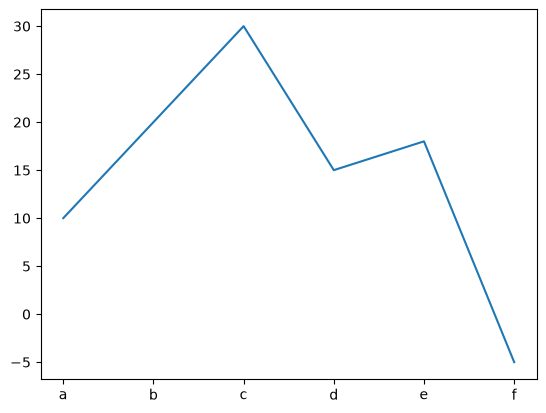

In [46]:
s = pd.Series([10, 20, 30, 15, 18, -5],
             index=list('abcdef'))

s.plot.line()   

<Axes: >

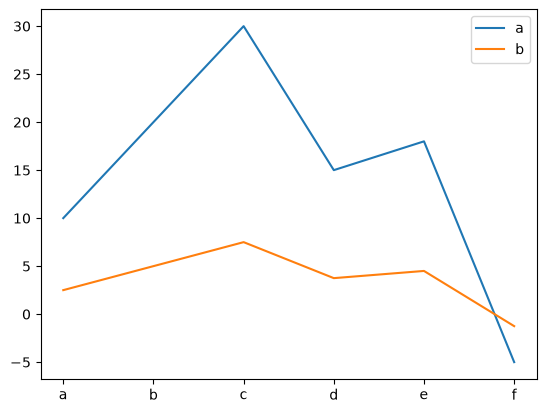

In [48]:
df = pd.DataFrame({'a':s, 
                   'b':s * 2 / 8})
df.plot.line()

<Axes: >

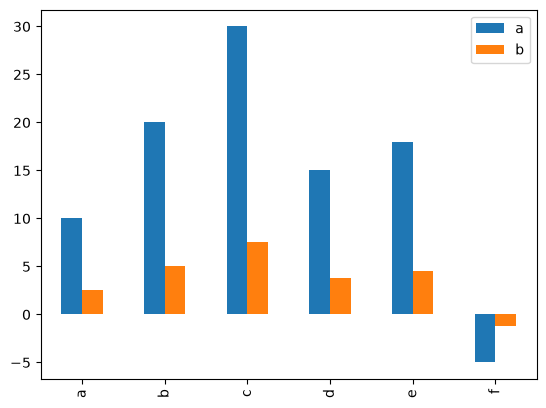

In [49]:
df.plot.bar()

<Axes: ylabel='Frequency'>

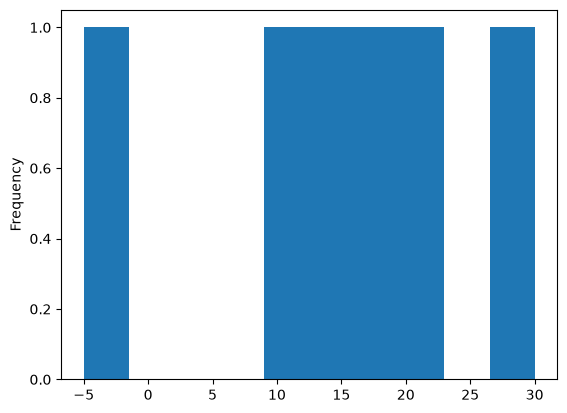

In [50]:
df['a'].plot.hist()

<Axes: >

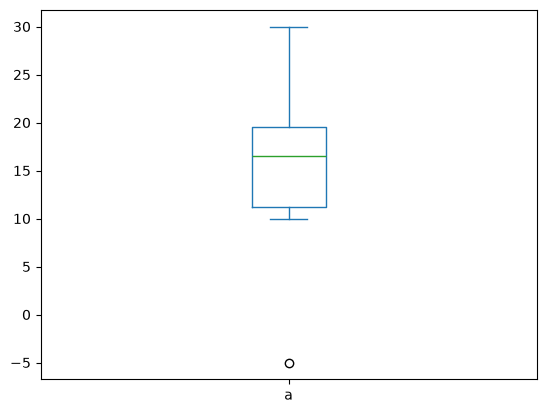

In [51]:
# boxplots are very useful in statistics, and unknown outside of that domain
# visual version of "describe"

df['a'].plot.box()

<Axes: >

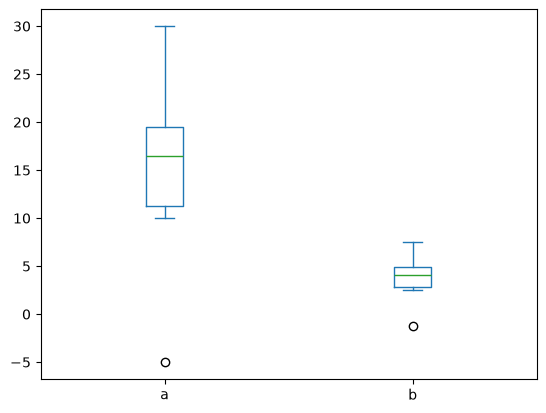

In [52]:
df.plot.box()

# Exercise: Plotting temperatures

1. Get the weather forecast for your city in the coming week, and create a data frame with the forecast high and low temps. The index should contain the days' names.
2. Create a line plot with the high temps. Then create a line plot with both.

3. Create a box plot with temps. What are the max, min, and median for both high and low temps in the coming 10 days?

https://practice.lernerpython.com/classroom/ce06963a8d/ex-71

In [53]:
df = pd.DataFrame({'high': [30, 30, 29, 29, 29, 29, 28, 27, 26, 27],
                   'low' : [20, 20, 20, 20, 20, 20, 18, 18, 18, 18]},
                  index='Fri Sat Sun Mon Tue Wed Thu Fri Sat Sun'.split())
df

,high,low
Fri,30,20
Sat,30,20
Sun,29,20
Mon,29,20
Tue,29,20
Wed,29,20
Thu,28,18
Fri,27,18
Sat,26,18
Sun,27,18


<Axes: >

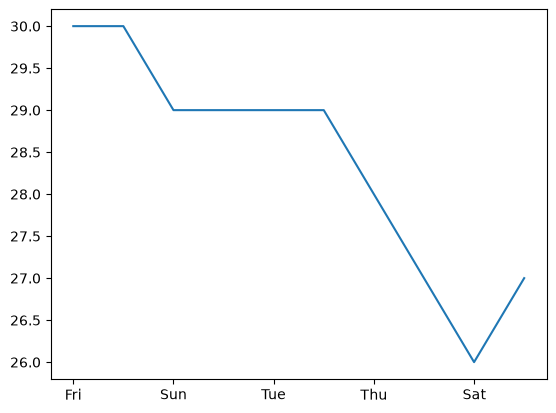

In [57]:
df['high'].plot.line()

<Axes: >

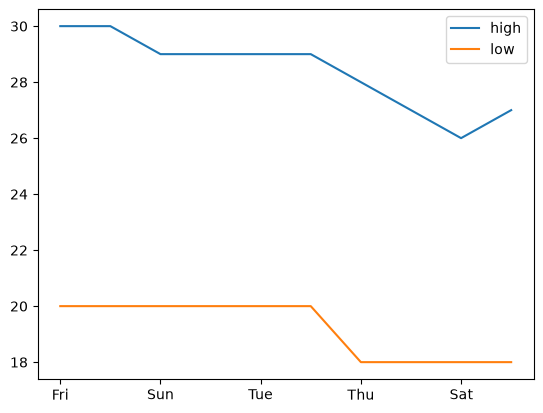

In [58]:
df.plot.line()

<Axes: >

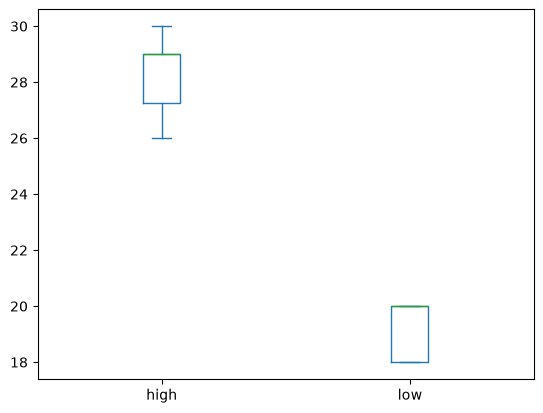

In [59]:
df.plot.box()

<Axes: ylabel='Frequency'>

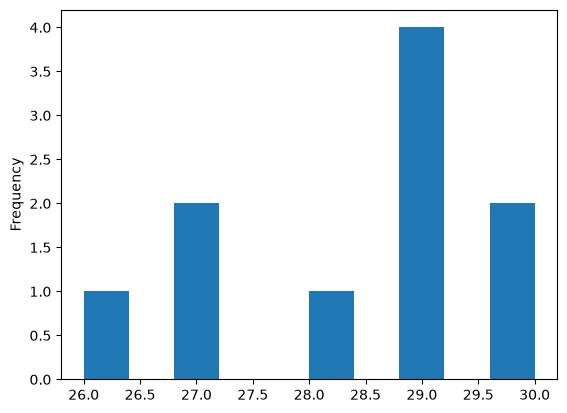

In [61]:
# what about a histogram?

df['high'].plot.hist()

In [62]:
df = pd.read_csv('taxi.csv')

<Axes: ylabel='Frequency'>

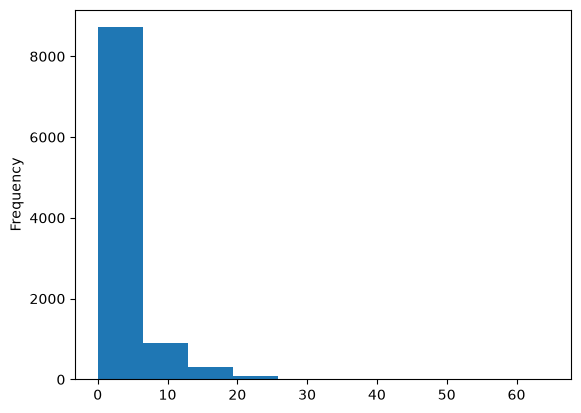

In [63]:
df['trip_distance'].plot.hist()

# Pie charts!

A pie chart sums the values in a series, and then shows how much each element contributes to that sum.

You almost certainly don't want to create a pie plot directly from a data frame. Rather, you'll usually want to perform `value_counts`, indicating how often each value appears, and then create a pie plot from that.

<Axes: >

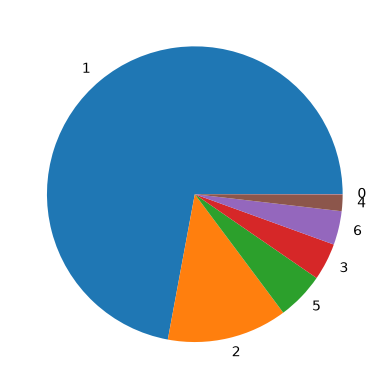

In [65]:
df['passenger_count'].value_counts().plot.pie()

In [66]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2015-06-02 11:19:29,2015-06-02 11:47:52,1,1.63,-73.954430,40.764141,1,N,-73.974754,40.754093,2,17.0,0.0,0.5,0.00,0.0,0.3,17.80
1,2,2015-06-02 11:19:30,2015-06-02 11:27:56,1,0.46,-73.971443,40.758942,1,N,-73.978539,40.761909,1,6.5,0.0,0.5,1.00,0.0,0.3,8.30
2,2,2015-06-02 11:19:31,2015-06-02 11:30:30,1,0.87,-73.978111,40.738434,1,N,-73.990273,40.745438,1,8.0,0.0,0.5,2.20,0.0,0.3,11.00
3,2,2015-06-02 11:19:31,2015-06-02 11:39:02,1,2.13,-73.945892,40.773529,1,N,-73.971527,40.760330,1,13.5,0.0,0.5,2.86,0.0,0.3,17.16
4,1,2015-06-02 11:19:32,2015-06-02 11:32:49,1,1.40,-73.979088,40.776772,1,N,-73.982162,40.758999,2,9.5,0.0,0.5,0.00,0.0,0.3,10.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,1,2015-06-01 00:12:59,2015-06-01 00:24:18,1,2.70,-73.947792,40.814972,1,N,-73.973358,40.783638,2,11.0,0.5,0.5,0.00,0.0,0.3,12.30
9995,1,2015-06-01 00:12:59,2015-06-01 00:28:16,1,4.50,-74.004066,40.747818,1,N,-73.953758,40.779285,1,16.0,0.5,0.5,3.00,0.0,0.3,20.30
9996,2,2015-06-01 00:13:00,2015-06-01 00:37:25,1,5.59,-73.994377,40.766102,1,N,-73.903206,40.750546,2,21.0,0.5,0.5,0.00,0.0,0.3,22.30
9997,2,2015-06-01 00:13:02,2015-06-01 00:19:10,6,1.54,-73.978302,40.748531,1,N,-73.989166,40.762852,2,6.5,0.5,0.5,0.00,0.0,0.3,7.80


<Axes: >

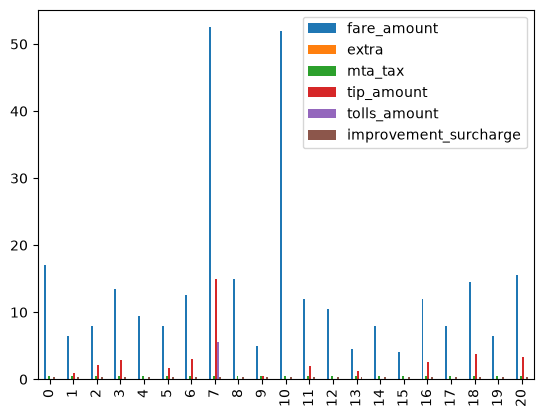

In [68]:
(
    df
    .loc[:20, ['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge']]  # first 20 taxi rides
   .plot.bar() 
)

<Axes: >

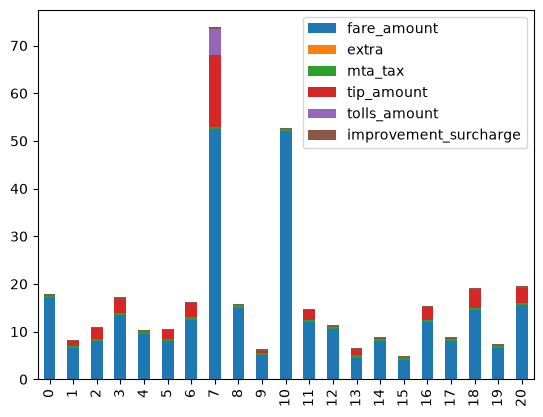

In [69]:
# stacked bar plot

(
    df
    .loc[:20, ['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge']]  # first 20 taxi rides
    .plot.bar(stacked=True) 
)

Do you pay more for a long taxi ride than a short one? Are these correlated?

Correlation is measured from -1 to +1:

- -1 means, perfectly negatively correlated
- 0 means, no correlation at all
- +1 means, perfectly positively correlated



In [70]:
df[['trip_distance', 'total_amount']].corr()

,trip_distance,total_amount
trip_distance,1.000000,0.880843
total_amount,0.880843,1.000000


<Axes: xlabel='trip_distance', ylabel='total_amount'>

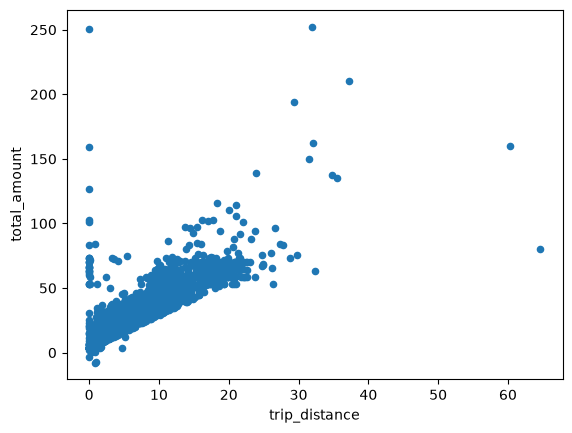

In [73]:
# graphical version of correlation -- scatterplot

df[['trip_distance', 'total_amount']].plot.scatter(x='trip_distance',
                                                  y='total_amount')

<Axes: xlabel='trip_distance', ylabel='total_amount'>

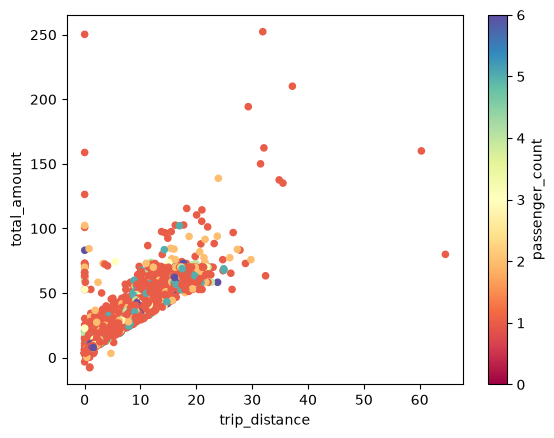

In [82]:
# we can add color by naming another column, and using it

df[['trip_distance', 'total_amount', 'passenger_count']].plot.scatter(x='trip_distance',
                                                  y='total_amount',
                                                  c='passenger_count', colormap='Spectral')